# CryptoGuard — RQ3 effect estimation and assessment

This restart-executable notebook retains the legacy developer-only versus developer-plus-third-party reporting-policy treatment and applies the current RQ1 graph assumptions. Association values are kept in the RQ1 result tables and are not printed on the graph.

In [1]:
from pathlib import Path
import sys
from IPython.display import SVG, display

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'causal_analysis').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'causal_analysis').is_dir():
    raise RuntimeError('Run this notebook from the ci4security repository')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from causal_analysis.shared.rq3_analysis import run_rq3_analysis

/Users/mkhan04/Desktop/projects/CauSec/ci4security/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


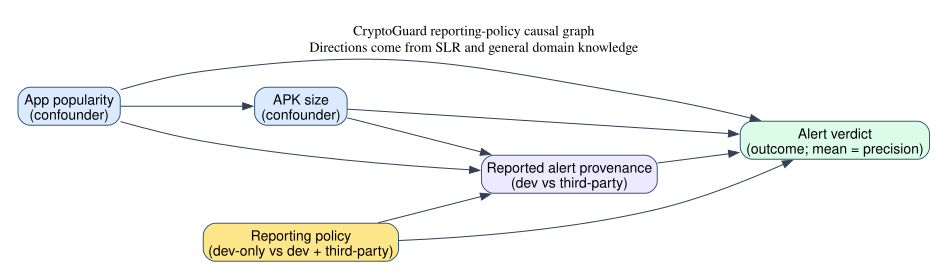

In [2]:
TOOL_NAME = 'CryptoGuard'
TOOL_SLUG = 'cryptoguard'
DATA_PATH = REPO_ROOT / 'causal_analysis/data/cryptoguard/alerts_with_lib_category_and_apk_size_cryptoguard.csv'
GRAPH_PATH = REPO_ROOT / 'causal_analysis/rq1_graph_assessment/graphs/causal_graph.svg'
OUTPUT_DIR = REPO_ROOT / 'causal_analysis/rq3_effect_estimation/results/cryptoguard'
BOOTSTRAP_SIMULATIONS = 1000
REFUTER_SIMULATIONS = 200
RANDOM_SEED = 20260917
display(SVG(filename=str(GRAPH_PATH)))

## Run the complete workflow

The workflow evaluates overlap and covariate balance; estimates the alert-row ATE risk difference with PSM, standardized logistic regression, and doubly robust AIPW; compares alert-row and popularity-stratified APK-cluster bootstraps; and runs the four legacy refuters plus an unobserved-common-cause sensitivity scenario.

In [3]:
analysis = run_rq3_analysis(
    tool_name=TOOL_NAME,
    source_path=DATA_PATH,
    graph_path=GRAPH_PATH,
    output_dir=OUTPUT_DIR,
    bootstrap_simulations=BOOTSTRAP_SIMULATIONS,
    refuter_simulations=REFUTER_SIMULATIONS,
    seed=RANDOM_SEED,
)
print(f'Results written to {OUTPUT_DIR}')

Results written to /Users/mkhan04/Desktop/projects/CauSec/ci4security/causal_analysis/rq3_effect_estimation/results/cryptoguard


In [4]:
display(analysis['overlap'])
display(analysis['balance'])
display(analysis['matching'])
display(analysis['estimator_results'])
display(analysis['refuters'])
display(analysis['software_validation'])

,reporting_policy,reporting_scope,n_rows,ps_min,ps_q01,ps_q05,ps_q25,ps_median,ps_q75,ps_q95,ps_q99,ps_max,common_support_lower,common_support_upper,n_outside_common_support,percent_outside_common_support,n_extreme_ps_below_0_1_or_above_0_9
0,0,developer_only,1318,0.899576,0.902157,0.903737,0.909948,0.914474,0.922650,0.951192,0.972584,0.975177,0.899576,0.975177,0,0.000000,1317
1,1,developer_plus_third_party,15272,0.898610,0.900896,0.903721,0.910355,0.919522,0.926637,0.951192,0.962433,0.979078,0.899576,0.975177,30,0.196438,15237


,covariate,smd_before,abs_smd_before,smd_after_psm,abs_smd_after_psm,balanced_after_psm_at_0_1,smd_after_aipw_weighting,abs_smd_after_aipw_weighting,balanced_after_aipw_weighting_at_0_1
0,app_popularity_encoded,0.106160,0.106160,-0.013155,0.013155,True,-0.023567,0.023567,True
1,apk_size_scaled,0.169001,0.169001,0.004567,0.004567,True,-0.097211,0.097211,True


,n_treated_rows,n_control_rows,common_support_lower,common_support_upper,n_rows_outside_common_support,percent_rows_outside_common_support,matching_with_replacement,unmatched_rows,unique_controls_used_for_att,unique_treated_used_for_atc,...,mean_atc_propensity_distance,max_atc_propensity_distance,diagnostic_logit_caliper_0_2_sd,att_pairs_above_diagnostic_caliper,atc_pairs_above_diagnostic_caliper,treated_effective_sample_size,control_effective_sample_size,aipw_treated_effective_sample_size,aipw_control_effective_sample_size,n_propensity_scores_clipped_at_0_01_or_0_99
0,15272,1318,0.899576,0.975177,30,0.180832,True,0,174,166,...,0.0,0.0,0.045447,118,0,3050.768156,137.387635,15268.715944,1208.384469,0


,estimator,estimator_label,effect_scale,target_units,estimate,row_bootstrap_successes,row_bootstrap_se,row_ci_low,row_ci_high,row_ci_width,row_ci_excludes_zero,cluster_bootstrap_successes,cluster_bootstrap_se,cluster_ci_low,cluster_ci_high,cluster_ci_width,cluster_ci_excludes_zero
0,psm,Propensity-score matching,risk_difference,ate,0.042556,1000,0.036628,-0.066920,0.076267,0.143187,False,1000,0.048867,-0.051542,0.140611,0.192153,False
1,logistic_regression,Logistic-regression adjustment,risk_difference,ate,-0.030417,1000,0.012068,-0.053872,-0.006114,0.047758,True,1000,0.076317,-0.178653,0.097791,0.276444,False
2,doubly_robust,Doubly robust (AIPW),risk_difference,ate,-0.022895,1000,0.012499,-0.046757,0.002231,0.048989,False,1000,0.050352,-0.143084,0.048433,0.191517,False


,estimator,refuter,result_index,original_effect,refuter_reference_effect,new_effect,absolute_change_from_original,relative_change_from_original,sign_changed_from_original,p_value,refuter_reports_significant_change,status,error
0,psm,random_common_cause,0,0.042556,0.042556,0.042556,0.000000e+00,0.000000e+00,False,1.00,False,success,None
1,psm,placebo_treatment_refuter,0,0.042556,0.042556,0.082864,4.030802e-02,9.471813e-01,False,0.02,True,success,None
2,psm,data_subset_refuter,0,0.042556,0.042556,-0.002527,4.508250e-02,1.059375e+00,True,0.13,False,success,None
3,psm,dummy_outcome_refuter,0,0.042556,0.000000,0.001019,4.153664e-02,9.760522e-01,False,0.97,False,success,None
4,psm,add_unobserved_common_cause,0,0.042556,0.042556,-0.160699,2.032550e-01,4.776204e+00,True,NaN,None,success,None
5,logistic_regression,random_common_cause,0,-0.030417,-0.030417,-0.030417,2.490521e-07,8.187921e-06,False,0.92,False,success,None
6,logistic_regression,placebo_treatment_refuter,0,-0.030417,-0.030417,0.000651,3.106836e-02,1.021414e+00,True,0.95,False,success,None
7,logistic_regression,data_subset_refuter,0,-0.030417,-0.030417,-0.029845,5.724393e-04,1.881971e-02,False,0.94,False,success,None
8,logistic_regression,dummy_outcome_refuter,0,-0.030417,0.000000,-0.003274,2.714306e-02,8.923643e-01,False,0.85,False,success,None
9,logistic_regression,add_unobserved_common_cause,0,-0.030417,-0.030417,-0.029255,1.162030e-03,3.820330e-02,False,NaN,None,success,None


,estimator,dowhy_estimate,independent_implementation_estimate,difference,agrees_within_1e_8
0,psm,0.042556,0.042556,0.000000e+00,True
1,logistic_regression,-0.030417,-0.030417,2.775558e-17,True
2,doubly_robust,-0.022895,-0.022895,-3.469447e-17,True
